# The perceptron

### One neuron, and the argument that stalled AI for a decade

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a single artificial neuron computes, the learning rule that trains it, why it cannot learn XOR, and how stacking two layers fixes that |
| **You should already know** | [Logistic regression](../../03-classification/01-logistic-regression/) |
| **Datasets** | Breast Cancer Wisconsin, plus the four points of XOR |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [07-02 MLP and backpropagation](../02-mlp-and-backpropagation/) |

---

## 1. The idea

Rosenblatt's perceptron, from 1958, is the ancestor of every neural network in
this book. It takes inputs, weights them, adds a bias, and fires if the total
clears zero:

$$\hat{y} = \begin{cases} 1 & \text{if } w \cdot x + b > 0 \\ 0 & \text{otherwise} \end{cases}$$

That is the same weighted sum as [linear regression](../../02-regression/01-linear-regression/),
with a hard threshold instead of a sigmoid. What made it famous is the **learning
rule**, which is one line and needs no calculus at all:

$$w \leftarrow w + \eta\,(y - \hat{y})\,x$$

Read it as a rule of thumb. Predicted 0 when the answer was 1? Push the weights
**toward** this input. Predicted 1 when it was 0? Push them **away**. Got it
right? Change nothing, because $(y - \hat{y})$ is zero.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. From scratch

In [2]:
class Perceptron:
    """Rosenblatt's perceptron, 1958."""

    def __init__(self, learning_rate=0.1, n_epochs=50):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, int)
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.errors_ = []

        for _ in range(self.n_epochs):
            mistakes = 0
            for xi, target in zip(X, y):
                # The update is zero whenever the prediction is already right,
                # so a perceptron only learns from its mistakes.
                delta = self.learning_rate * (target - self.predict_one(xi))
                self.w_ += delta * xi
                self.b_ += delta
                mistakes += int(delta != 0.0)
            self.errors_.append(mistakes)
            if mistakes == 0:
                break                     # converged: nothing left to learn from
        return self

    def predict_one(self, x):
        return int(x @ self.w_ + self.b_ > 0.0)

    def predict(self, X):
        return (np.asarray(X, float) @ self.w_ + self.b_ > 0.0).astype(int)


from sklearn.preprocessing import StandardScaler

X_bc, y_bc = datasets.breast_cancer()
X_scaled = StandardScaler().fit_transform(X_bc)

model = Perceptron(learning_rate=0.1, n_epochs=50).fit(X_scaled, y_bc)
print(f"stopped after {len(model.errors_)} epochs")
print(f"mistakes in the first epoch : {model.errors_[0]}")
print(f"mistakes in the last epoch  : {model.errors_[-1]}")
print(f"training accuracy           : {(model.predict(X_scaled) == y_bc).mean():.4f}")

stopped after 50 epochs
mistakes in the first epoch : 40
mistakes in the last epoch  : 18
training accuracy           : 0.9789


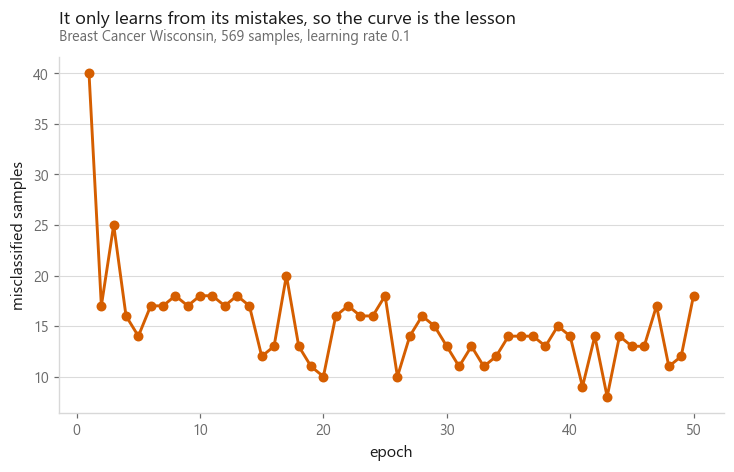

In [3]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(range(1, len(model.errors_) + 1), model.errors_, marker=style.MARKERS[0],
        color=style.HIGHLIGHT)
ax.set_xlabel("epoch")
ax.set_ylabel("misclassified samples")
style.title(ax, "It only learns from its mistakes, so the curve is the lesson",
            "Breast Cancer Wisconsin, 569 samples, learning rate 0.1")
style.save(fig, FIG / "fig-01-convergence.png")

**Rosenblatt's convergence theorem** guarantees this: if the classes can be
separated by a straight line, the perceptron will find one in a finite number of
steps. If they cannot, it never settles: it cycles forever, and there is no
warning that it is doing so.

## 3. The XOR problem

In 1969 Minsky and Papert pointed out something that a single perceptron cannot
do, and it is embarrassingly small. Four points:

| input 1 | input 2 | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Try to draw one straight line with both 1s on one side and both 0s on the other.
There isn't one. The 1s sit on opposite corners.

 AND: accuracy 1.00, ran 6 epochs, converged
  OR: accuracy 1.00, ran 4 epochs, converged
 XOR: accuracy 0.50, ran 200 epochs, never converged


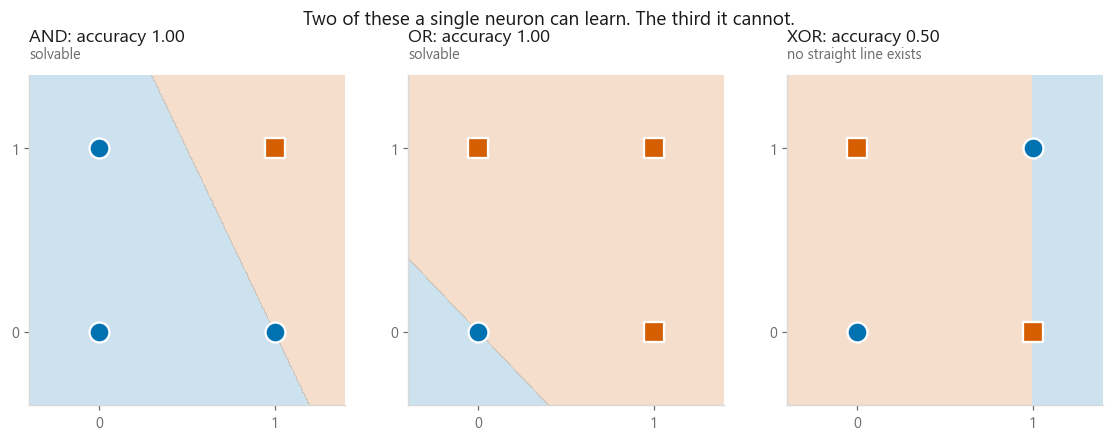

In [4]:
XOR_X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
XOR_y = np.array([0, 1, 1, 0])
AND_y = np.array([0, 0, 0, 1])
OR_y = np.array([0, 1, 1, 1])

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9))
for ax, (name, target) in zip(axes, [("AND", AND_y), ("OR", OR_y), ("XOR", XOR_y)]):
    trained = Perceptron(learning_rate=0.1, n_epochs=200).fit(XOR_X, target)
    accuracy = (trained.predict(XOR_X) == target).mean()

    xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 200), np.linspace(-0.4, 1.4, 200))
    zz = trained.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=[style.PALETTE[0], style.HIGHLIGHT],
                alpha=0.20)

    for value, colour, marker in [(0, style.PALETTE[0], "o"), (1, style.HIGHLIGHT, "s")]:
        sel = target == value
        ax.scatter(XOR_X[sel, 0], XOR_X[sel, 1], s=170, c=colour, marker=marker,
                   edgecolors="white", linewidths=1.5, zorder=3)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.grid(False)
    style.title(ax, f"{name}: accuracy {accuracy:.2f}",
                "solvable" if accuracy == 1.0 else "no straight line exists")

fig.suptitle("Two of these a single neuron can learn. The third it cannot.",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-xor.png")

for name, target in [("AND", AND_y), ("OR", OR_y), ("XOR", XOR_y)]:
    trained = Perceptron(learning_rate=0.1, n_epochs=200).fit(XOR_X, target)
    print(f"{name:>4}: accuracy {(trained.predict(XOR_X) == target).mean():.2f}, "
          f"ran {len(trained.errors_)} epochs, "
          f"{'converged' if trained.errors_[-1] == 0 else 'never converged'}")

AND and OR converge immediately. XOR runs all 200 epochs and never settles,
ending at 0.50 accuracy, no better than a coin toss on four points.

This result, published as *Perceptrons* in 1969, is widely credited with draining
funding and attention from neural networks for most of the 1970s. The awkward
part of the history is that the fix was already understood in principle:
**stack another layer.**

## 4. Two layers solve it

XOR is `(A OR B) AND NOT (A AND B)`. A single neuron can compute OR. Another can
compute AND. A third can combine them. The trick is that the middle layer builds
*new features*, and in that new space, the problem becomes linearly separable.

single perceptron on XOR : 0.50
one hidden layer on XOR  : 1.00

hidden layer activations, one row per input:
       unit 1  unit 2  unit 3  unit 4
(0,0)  -0.840  -0.977  -0.478  -0.853
(0,1)   0.963  -0.800   0.331  -0.999
(1,0)   0.891  -0.217  -0.906   0.625
(1,1)   1.000   0.719  -0.565  -0.958


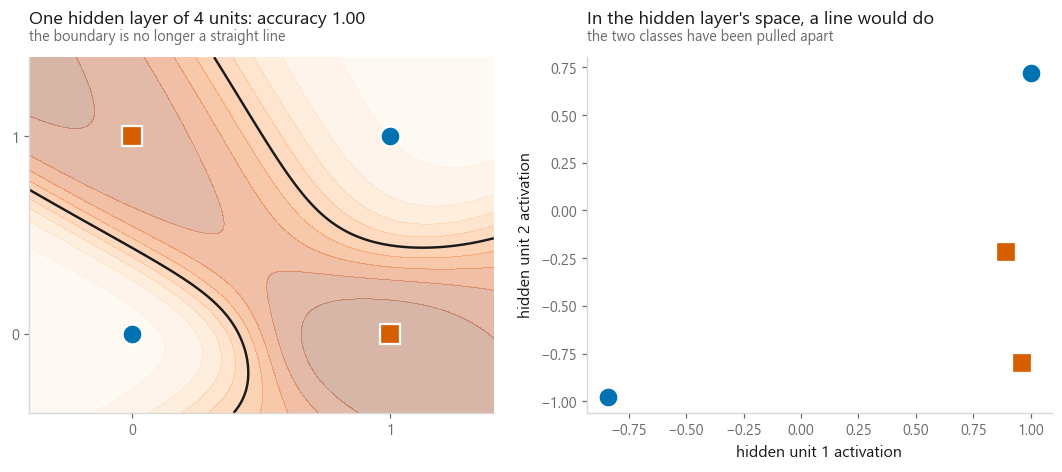

In [5]:
from sklearn.neural_network import MLPClassifier

network = MLPClassifier(hidden_layer_sizes=(4,), activation="tanh", max_iter=6000,
                        random_state=3).fit(XOR_X, XOR_y)

hidden = np.tanh(XOR_X @ network.coefs_[0] + network.intercepts_[0])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 300), np.linspace(-0.4, 1.4, 300))
zz = network.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
axes[0].contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap="Oranges", alpha=0.35)
axes[0].contour(xx, yy, zz, levels=[0.5], colors=[style.INK], linewidths=1.6)
for value, colour, marker in [(0, style.PALETTE[0], "o"), (1, style.HIGHLIGHT, "s")]:
    sel = XOR_y == value
    axes[0].scatter(XOR_X[sel, 0], XOR_X[sel, 1], s=170, c=colour, marker=marker,
                    edgecolors="white", linewidths=1.5, zorder=3)
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].grid(False)
style.title(axes[0], f"One hidden layer of 4 units: accuracy "
                     f"{network.score(XOR_X, XOR_y):.2f}",
            "the boundary is no longer a straight line")

# The first two hidden units, showing what the middle layer rebuilt.
for value, colour, marker in [(0, style.PALETTE[0], "o"), (1, style.HIGHLIGHT, "s")]:
    sel = XOR_y == value
    axes[1].scatter(hidden[sel, 0], hidden[sel, 1], s=170, c=colour, marker=marker,
                    edgecolors="white", linewidths=1.5, zorder=3)
axes[1].grid(False)
axes[1].set_xlabel("hidden unit 1 activation")
axes[1].set_ylabel("hidden unit 2 activation")
style.title(axes[1], "In the hidden layer's space, a line would do",
            "the two classes have been pulled apart")

style.save(fig, FIG / "fig-03-two-layers.png")

print(f"single perceptron on XOR : 0.50")
print(f"one hidden layer on XOR  : {network.score(XOR_X, XOR_y):.2f}")
print("\nhidden layer activations, one row per input:")
print(pd.DataFrame(np.round(hidden, 3),
                   index=["(0,0)", "(0,1)", "(1,0)", "(1,1)"],
                   columns=[f"unit {i+1}" for i in range(hidden.shape[1])]).to_string())

The right panel is the whole idea of deep learning in one picture. The hidden
layer took four points that no line could separate and **moved them** into
positions where a line can. Every layer after the first is doing classification;
the layers before it are inventing the features that make classification easy.

The catch, and the reason this took until the 1980s to become practical: the
perceptron rule cannot train a hidden layer. It needs to know each unit's error,
and there is no target for a hidden unit: nobody says what it *should* have
output. Solving that is [backpropagation](../02-mlp-and-backpropagation/), the
next notebook.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Almost never in production: it is here because everything else descends from it |
| **Guarantee** | Converges in finite steps **if** the data is linearly separable. Otherwise it cycles forever with no warning |
| **Versus logistic regression** | Same weighted sum. The perceptron thresholds hard and gives no probabilities; logistic regression uses a sigmoid and does |
| **Scaling needed** | Yes, as for any distance- or gradient-based method |
| **Watch out** | It stops at the *first* separating line it finds, which may sit right against the data. An [SVM](../../03-classification/05-support-vector-machines/) picks the best one |

## What to remember

1. A perceptron is a weighted sum with a hard threshold.
2. Its rule updates only on mistakes, and needs no calculus.
3. It converges if and only if a straight line separates the classes.
4. XOR has no such line, and a single neuron fails on four points.
5. A hidden layer fixes it by *rebuilding the input space* so a line will do.
6. Training that hidden layer needs backpropagation, which is the next notebook.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-02 MLP and backpropagation](../02-mlp-and-backpropagation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#DeepLearning` `#Perceptron` `#NeuralNetwork` `#XOR`
`#Python` `#NumPy` `#MLTutorial` `#LearnMachineLearning` `#AI`